In [18]:
import numpy as np
import shap

print(np.__version__)
print(shap.__version__)


1.24.3
0.46.0


In [5]:
import sys
import os

sys.path.append(os.path.abspath(".."))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

import shap

from src.preprocess import preprocess_data


In [6]:
df = pd.read_csv("../data/raw/diabetic_data.csv")

X, y = preprocess_data(df)

print(X.shape)


(101766, 47)


In [7]:
model = joblib.load("../models/best_model.pkl")

model

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['admission_type_id',
                                                   'discharge_disposition_id',
                                                   'admission_source_id',
                                                   'time_in_hospital',
                                                   'num_lab_procedures',
                                                   'num_procedures',
                                                   'num_medications',
                                                   'number_outpatient',
                                                   'number_emergency',
                                                   'number_inpatient',
                                                   'number_diagnoses']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='i...
                                                   'metformin', 'repaglinide',
                                                   'nateglinide',
                                                   'chlorpropamide',
                                                   'glimepiride',
                                                   'acetohexamide', 'glipizide',
                                                   'glyburide', 'tolbutamide',
                                                   'pioglitazone',
                                                   'rosiglitazone', 'acarbose',
                                                   'miglitol', 'troglitazone',
                                                   'tolazamide', 'examide',
                                                   'citoglipton', 'insulin',
                                                   'glyburide-metformin', ...])])),
                ('model',
                 GradientBoostingClassifier(learning_rate=0.05,
                                            n_estimators=200,
                                            random_state=42))])

In [8]:
#splitting data for explanation 
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [9]:
#Because the pipeline contains preprocessing, extracting the internal pieces.
preprocessor = model.named_steps["preprocessor"]
clf = model.named_steps["model"]

X_transformed = preprocessor.transform(X_test)


In [10]:
feature_names = preprocessor.get_feature_names_out()
len(feature_names)

2379

In [11]:
importances = clf.feature_importances_

importance_df = pd.DataFrame({
    "feature": feature_names,
    "importance": importances
})
importance_df = importance_df.sort_values("importance", ascending=False)
importance_df.head(15)


,feature,importance
9,num__number_inpatient,0.475788
1,num__discharge_disposition_id,0.229641
817,cat__diag_1_V58,0.024862
8,num__number_emergency,0.017590
3,num__time_in_hospital,0.014726
56,cat__payer_code_Unknown,0.013436
10,num__number_diagnoses,0.012612
4,num__num_lab_procedures,0.008252
1639,cat__diag_3_250.6,0.007593
6,num__num_medications,0.006837


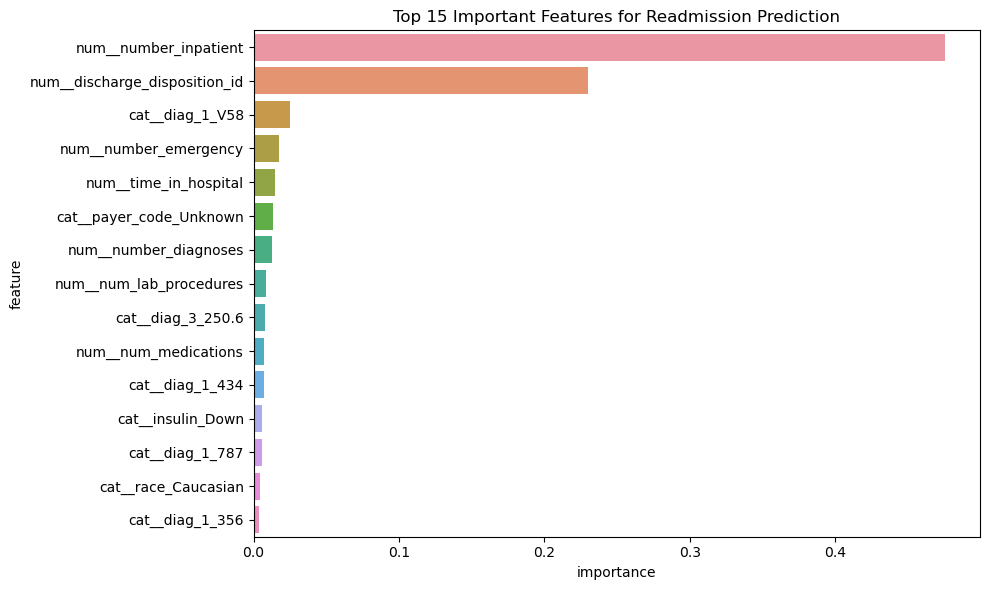

In [12]:
top_features = importance_df.head(15)

plt.figure(figsize=(10,6))

sns.barplot(
    data=top_features,
    x="importance",
    y="feature"
)

plt.title("Top 15 Important Features for Readmission Prediction")
plt.tight_layout()
plt.show()


In [ ]:
import numpy as np

# Convering transformed features to dense numeric array
if hasattr(X_transformed, "toarray"):
    X_shap = X_transformed.toarray()
else:
    X_shap = np.array(X_transformed)

X_shap = X_shap.astype(np.float32)

explainer = shap.TreeExplainer(clf)
shap_values = explainer.shap_values(X_shap)


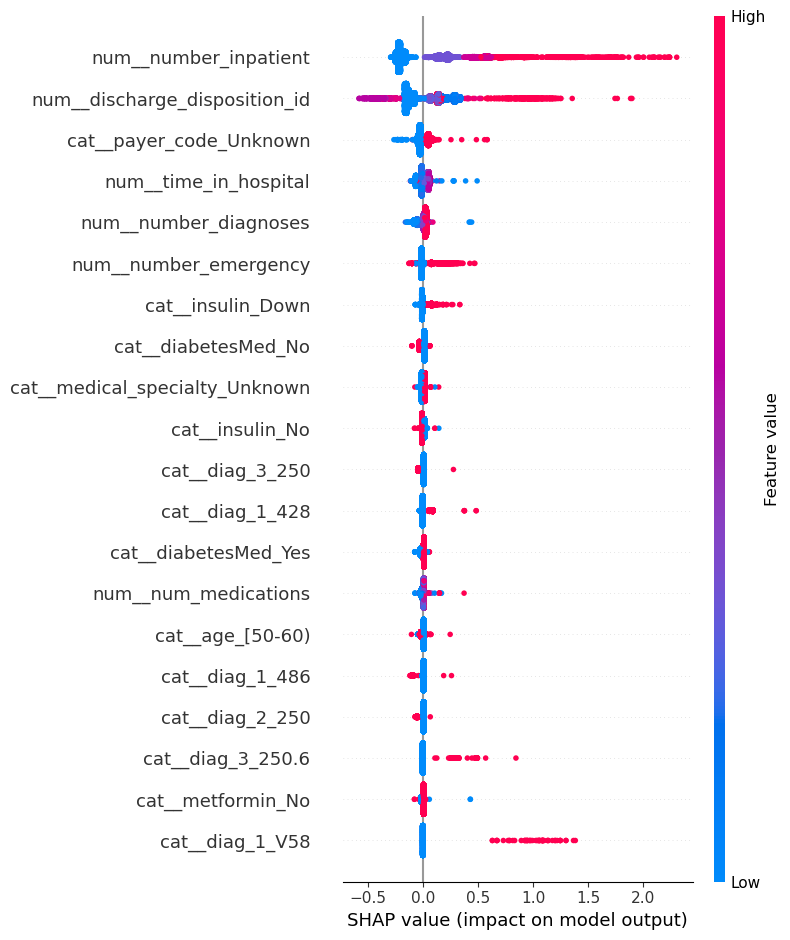

In [15]:
shap.summary_plot(
    shap_values,
    X_shap,
    feature_names=feature_names
)

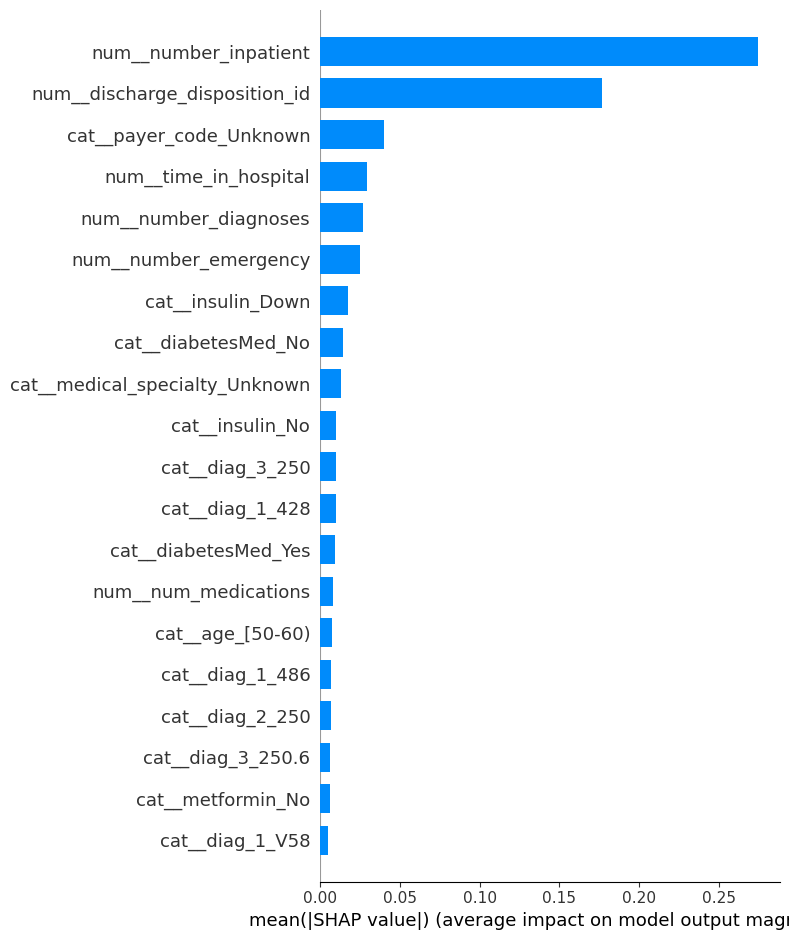

In [16]:
shap.summary_plot(
    shap_values,
    X_shap,
    feature_names=feature_names,
    plot_type="bar"
)

In [17]:
sample_index = 10

shap.initjs()
shap.force_plot(
    explainer.expected_value,
    shap_values[sample_index],
    features=X_shap[sample_index],
    feature_names=feature_names
)